## Setup

In [1]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

sc.settings.verbosity = 1

print("Setup complete")

Setup complete


## Load and Explore Data

In [2]:
adata = sc.read_h5ad("data/752ed29d-bbb0-45bd-9c57-19edf68ef73e.h5ad")
adata

AnnData object with n_obs × n_vars = 79667 × 20929
    obs: 'age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'n_genes', 'n_counts', 'clust_annot', 'sex_ontology_term_id', 'suspension_type', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'is_primary_data', 'cell_type_annot', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'feature_is_filtered', 'mean', 'std', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'age_colors', 'batch_condition', 'citation', 'is_pre_analysis', 'leiden', 'neighbors', 'organism', 'organism_ontology_term_id', 'pca', 'schema_reference', 'schema_version', 'title', 'umap'
    obsm: '

In [3]:
adata.obs["cell_type"].value_counts()

cell_type
neuron                            30517
oligodendrocyte                   18254
medium spiny neuron                9847
astrocyte                          6771
inhibitory interneuron             5999
microglial cell                    3341
oligodendrocyte precursor cell     3291
endothelial cell                    401
vascular leptomeningeal cell        350
cell                                339
pericyte                            281
macrophage                          169
T cell                              107
Name: count, dtype: int64

## Split Young vs. Old

In [4]:
adata.obs["age"].value_counts()

age
4wk     40972
90wk    38695
Name: count, dtype: int64

In [5]:
adata_young = adata[adata.obs["age"] == "4wk"].copy()
adata_old = adata[adata.obs["age"] == "90wk"].copy()

print("Young cells:", adata_young.n_obs)
print("Old cells:", adata_old.n_obs)

Young cells: 40972
Old cells: 38695


In [6]:
adata.var.head()

,n_cells,highly_variable,means,dispersions,dispersions_norm,feature_is_filtered,mean,std,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSMUSG00000051951,148655,False,1.907681,0.375656,-0.508109,False,1.531457,0.580868,Xkr4,NCBITaxon:10090,gene,3634,protein_coding
ENSMUSG00000025900,970,False,0.010263,1.079661,0.799545,False,0.006514,0.088125,Rp1,NCBITaxon:10090,gene,4170,protein_coding
ENSMUSG00000025902,449,True,0.009896,1.575143,2.384793,False,0.003727,0.078591,Sox17,NCBITaxon:10090,gene,1509,protein_coding
ENSMUSG00000033845,36370,False,0.314031,0.741590,-0.341392,False,0.218257,0.462751,Mrpl15,NCBITaxon:10090,gene,1569,protein_coding
ENSMUSG00000025903,46512,False,0.461195,0.905833,0.552562,False,0.311440,0.557048,Lypla1,NCBITaxon:10090,gene,903,protein_coding


## Ligand-Receptor Analysis - Young Group

In [7]:
adata_young.var["feature_name_upper"] = adata_young.var["feature_name"].astype(str).str.upper()

sq.gr.ligrec(
    adata_young,
    cluster_key="cell_type",
    n_perms=100,
    seed=0,
    gene_symbols="feature_name_upper",
    use_raw=False,
)


  0%|          | 0/100 [00:00<?, ?permutation/s]

In [9]:
glia_targets = ["astrocyte", "microglial cell", "oligodendrocyte", "oligodendrocyte precursor cell"]

In [10]:
results_young = adata_young.uns["cell_type_ligrec"]
pvals_young = results_young["pvalues"]
means_young = results_young["means"]

pvals_glia_young = pvals_young[[("neuron", t) for t in glia_targets]]
means_glia_young = means_young[[("neuron", t) for t in glia_targets]]

sig_glia_young = pvals_glia_young[(pvals_glia_young < 0.05).any(axis=1)]
print("Significant neuron→glia pairs (young):", len(sig_glia_young))

top_hits_young = means_glia_young.loc[sig_glia_young.index].copy()
top_hits_young["max_mean"] = top_hits_young.max(axis=1)
top_hits_young_sorted = top_hits_young.sort_values("max_mean", ascending=False)

top_hits_young_sorted.head(20)

Significant neuron→glia pairs (young): 1557


neuron                                  \
              astrocyte microglial cell oligodendrocyte   
source target                                             
IL34   CSF1R          0        2.306908               0   
NRP1   PDGFRA         0               0               0   
PDGFC  PDGFRA         0               0               0   
VEGFC  PDGFRA         0               0               0   
FGF12  PDGFRA         0               0               0   
PDGFB  PDGFRA         0               0               0   
FGF5   PDGFRA         0               0               0   
FGF10  PDGFRA         0               0               0   
SOCS2  CSF3R          0          2.1278               0   
PDGFA  PDGFRA         0               0               0   
CX3CL1 CCR5           0        2.107798               0   
FGF9   PDGFRA         0               0               0   
EPOR   INPP5D         0        2.104187               0   
CCN2   ITGAM          0        2.100204               0   
CX3CL1 CX3CR1         0        2.098695               0   
EGF    PDGFRA         0               0               0   
FGF14  PDGFRA         0               0               0   
VEGFD  PDGFRA         0               0               0   
PGF    PDGFRA         0               0               0   
FGF22  PDGFRA         0               0               0   

                                              max_mean  
              oligodendrocyte precursor cell            
source target                                           
IL34   CSF1R                               0  2.306908  
NRP1   PDGFRA                        2.28753   2.28753  
PDGFC  PDGFRA                        2.24482   2.24482  
VEGFC  PDGFRA                       2.232739  2.232739  
FGF12  PDGFRA                        2.20166   2.20166  
PDGFB  PDGFRA                       2.167212  2.167212  
FGF5   PDGFRA                       2.166132  2.166132  
FGF10  PDGFRA                        2.15846   2.15846  
SOCS2  CSF3R                               0    2.1278  
PDGFA  PDGFRA                       2.126869  2.126869  
CX3CL1 CCR5                                0  2.107798  
FGF9   PDGFRA                       2.106556  2.106556  
EPOR   INPP5D                              0  2.104187  
CCN2   ITGAM                               0  2.100204  
CX3CL1 CX3CR1                              0  2.098695  
EGF    PDGFRA                       2.094897  2.094897  
FGF14  PDGFRA                       2.086345  2.086345  
VEGFD  PDGFRA                       2.078772  2.078772  
PGF    PDGFRA                       2.068838  2.068838  
FGF22  PDGFRA                       2.065378  2.065378

## Ligand-Receptor Analysis - Old Group

In [11]:
adata_old.var["feature_name_upper"] = adata_old.var["feature_name"].astype(str).str.upper()

sq.gr.ligrec(
    adata_old,
    cluster_key="cell_type",
    n_perms=100,
    seed=0,
    gene_symbols="feature_name_upper",
    use_raw=False,
)

  0%|          | 0/100 [00:00<?, ?permutation/s]

In [12]:
results_old = adata_old.uns["cell_type_ligrec"]
pvals_old = results_old["pvalues"]
means_old = results_old["means"]

pvals_glia_old = pvals_old[[("neuron", t) for t in glia_targets]]
means_glia_old = means_old[[("neuron", t) for t in glia_targets]]

sig_glia_old = pvals_glia_old[(pvals_glia_old < 0.05).any(axis=1)]
print("Significant neuron→glia pairs (old):", len(sig_glia_old))

top_hits_old = means_glia_old.loc[sig_glia_old.index].copy()
top_hits_old["max_mean"] = top_hits_old.max(axis=1)
top_hits_old_sorted = top_hits_old.sort_values("max_mean", ascending=False)

top_hits_old_sorted.head(20)

Significant neuron→glia pairs (old): 1759


neuron                                  \
              astrocyte microglial cell oligodendrocyte   
source target                                             
SOCS2  CSF3R          0        2.540641               0   
FGF10  PDGFRA         0               0               0   
FGF5   PDGFRA         0               0               0   
THPO   CSF3R          0        2.313748               0   
NRP1   PDGFRA         0               0               0   
PDGFB  PDGFRA         0               0               0   
FGF12  PDGFRA         0               0               0   
IL34   CSF1R          0        2.265708               0   
HGF    PDGFRA         0               0               0   
VEGFC  PDGFRA         0               0               0   
THY1   ITGAM          0        2.234933               0   
EPO    CSF3R          0        2.229307               0   
PDGFC  PDGFRA         0               0               0   
PDGFA  PDGFRA         0               0               0   
VEGFD  PDGFRA         0               0               0   
FGF9   PDGFRA         0               0               0   
FGF22  PDGFRA         0               0               0   
FGF7   PDGFRA         0               0               0   
VEGFB  PDGFRA         0               0               0   
PGF    PDGFRA         0               0               0   

                                              max_mean  
              oligodendrocyte precursor cell            
source target                                           
SOCS2  CSF3R                               0  2.540641  
FGF10  PDGFRA                       2.392305  2.392305  
FGF5   PDGFRA                       2.380887  2.380887  
THPO   CSF3R                               0  2.313748  
NRP1   PDGFRA                       2.308499  2.308499  
PDGFB  PDGFRA                       2.298959  2.298959  
FGF12  PDGFRA                       2.271176  2.271176  
IL34   CSF1R                               0  2.265708  
HGF    PDGFRA                       2.243653  2.243653  
VEGFC  PDGFRA                       2.235002  2.235002  
THY1   ITGAM                               0  2.234933  
EPO    CSF3R                               0  2.229307  
PDGFC  PDGFRA                       2.220769  2.220769  
PDGFA  PDGFRA                       2.218204  2.218204  
VEGFD  PDGFRA                       2.209301  2.209301  
FGF9   PDGFRA                       2.206554  2.206554  
FGF22  PDGFRA                       2.201317  2.201317  
FGF7   PDGFRA                       2.190555  2.190555  
VEGFB  PDGFRA                       2.184522  2.184522  
PGF    PDGFRA                       2.178706  2.178706

## Compare Young vs. Old Top Pairs

In [13]:
young_pairs = set(top_hits_young_sorted.head(20).index)
old_pairs = set(top_hits_old_sorted.head(20).index)

In [14]:
only_young = young_pairs - old_pairs
only_old = old_pairs - young_pairs
shared_pairs = young_pairs & old_pairs

print("Only in YOUNG top 20:", only_young)
print("\nOnly in OLD top 20:", only_old)
print("\nShared in both top 20:", shared_pairs)

Only in YOUNG top 20: {('CX3CL1', 'CCR5'), ('CCN2', 'ITGAM'), ('FGF14', 'PDGFRA'), ('EGF', 'PDGFRA'), ('EPOR', 'INPP5D'), ('CX3CL1', 'CX3CR1')}

Only in OLD top 20: {('THPO', 'CSF3R'), ('FGF7', 'PDGFRA'), ('VEGFB', 'PDGFRA'), ('HGF', 'PDGFRA'), ('THY1', 'ITGAM'), ('EPO', 'CSF3R')}

Shared in both top 20: {('IL34', 'CSF1R'), ('SOCS2', 'CSF3R'), ('VEGFD', 'PDGFRA'), ('FGF12', 'PDGFRA'), ('FGF22', 'PDGFRA'), ('NRP1', 'PDGFRA'), ('PGF', 'PDGFRA'), ('FGF10', 'PDGFRA'), ('PDGFA', 'PDGFRA'), ('FGF5', 'PDGFRA'), ('PDGFC', 'PDGFRA'), ('PDGFB', 'PDGFRA'), ('VEGFC', 'PDGFRA'), ('FGF9', 'PDGFRA')}


## Verifying Findings (Raw Value Checks)

In [15]:
pair = ("CX3CL1", "CX3CR1")

print("Young means:", means_glia_young.loc[pair] if pair in means_glia_young.index else "not tested/significant")
print("Old means:", means_glia_old.loc[pair] if pair in means_glia_old.index else "not tested/significant")

print("Young p-value:", pvals_glia_young.loc[pair] if pair in pvals_glia_young.index else "not tested/significant")
print("Old p-value:", pvals_glia_old.loc[pair] if pair in pvals_glia_old.index else "not tested/significant")

Young means: neuron  astrocyte                                0
        microglial cell                   2.098695
        oligodendrocyte                          0
        oligodendrocyte precursor cell           0
Name: (CX3CL1, CX3CR1), dtype: Sparse[float64, 0]
Old means: neuron  astrocyte                                0
        microglial cell                   2.095824
        oligodendrocyte                          0
        oligodendrocyte precursor cell           0
Name: (CX3CL1, CX3CR1), dtype: Sparse[float64, 0]
Young p-value: neuron  astrocyte                         NaN
        microglial cell                   0.0
        oligodendrocyte                   NaN
        oligodendrocyte precursor cell    NaN
Name: (CX3CL1, CX3CR1), dtype: Sparse[float64, nan]
Old p-value: neuron  astrocyte                         NaN
        microglial cell                   0.0
        oligodendrocyte                   NaN
        oligodendrocyte precursor cell    NaN
Name: (CX3CL1, CX3CR

In [16]:
pair = ("THY1", "ITGAM")

print("Young means:", means_glia_young.loc[pair] if pair in means_glia_young.index else "not tested/significant")
print("Old means:", means_glia_old.loc[pair] if pair in means_glia_old.index else "not tested/significant")

Young means: not tested/significant
Old means: neuron  astrocyte                                0
        microglial cell                   2.234933
        oligodendrocyte                          0
        oligodendrocyte precursor cell           0
Name: (THY1, ITGAM), dtype: Sparse[float64, 0]


In [17]:
pair = ("THY1", "ITGAM")

# Check raw values regardless of significance filtering
print("Young raw means:")
print(means_young.loc[pair] if pair in means_young.index else "pair not in results at all")

print("\nYoung raw p-value:")
print(pvals_young.loc[pair] if pair in pvals_young.index else "pair not in results at all")

Young raw means:
pair not in results at all

Young raw p-value:
pair not in results at all


In [18]:
print("THY1" in adata_young.var["feature_name_upper"].values)
print("ITGAM" in adata_young.var["feature_name_upper"].values)

True
True


In [19]:
for pair in [("FGF7", "PDGFRA"), ("HGF", "PDGFRA"), ("VEGFB", "PDGFRA"), ("EPO", "CSF3R"), ("THPO", "CSF3R")]:
    in_young = pair in means_young.index
    print(pair, "— in young results:", in_young)
    if in_young:
        print("  young mean:", means_young.loc[pair].max(), "young p:", pvals_young.loc[pair].min())
    print("  old mean:", means_old.loc[pair].max(), "old p:", pvals_old.loc[pair].min())
    print()

('FGF7', 'PDGFRA') — in young results: True
  young mean: 2.1250856532054057 young p: 0.0
  old mean: 2.2292012609309277 old p: 0.0

('HGF', 'PDGFRA') — in young results: True
  young mean: 2.6582649100577713 young p: 0.0
  old mean: 2.733111896494389 old p: 0.0

('VEGFB', 'PDGFRA') — in young results: True
  young mean: 2.163960948624218 young p: 0.0
  old mean: 2.3468827817192333 old p: 0.0

('EPO', 'CSF3R') — in young results: True
  young mean: 2.0911829593894975 young p: 0.0
  old mean: 2.2611140071564813 old p: 0.0

('THPO', 'CSF3R') — in young results: True
  young mean: 1.961274624500721 young p: 0.0
  old mean: 2.3137477691548463 old p: 0.0



## Final Visualization

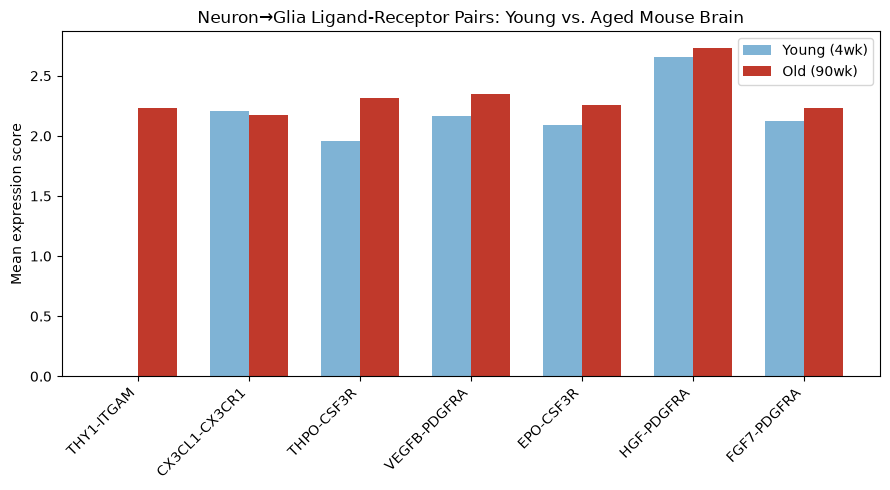

In [20]:
import matplotlib.pyplot as plt
import numpy as np

pairs_to_plot = [
    ("THY1", "ITGAM"),
    ("CX3CL1", "CX3CR1"),
    ("THPO", "CSF3R"),
    ("VEGFB", "PDGFRA"),
    ("EPO", "CSF3R"),
    ("HGF", "PDGFRA"),
    ("FGF7", "PDGFRA"),
]

young_vals = []
old_vals = []
labels = []

for pair in pairs_to_plot:
    y_val = means_young.loc[pair].max() if pair in means_young.index else 0
    o_val = means_old.loc[pair].max() if pair in means_old.index else 0
    young_vals.append(y_val)
    old_vals.append(o_val)
    labels.append(f"{pair[0]}-{pair[1]}")

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, young_vals, width, label="Young (4wk)", color="#7fb3d5")
ax.bar(x + width/2, old_vals, width, label="Old (90wk)", color="#c0392b")

ax.set_ylabel("Mean expression score")
ax.set_title("Neuron→Glia Ligand-Receptor Pairs: Young vs. Aged Mouse Brain")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.savefig("final_comparison.png", dpi=200, bbox_inches="tight")
plt.show()